# A quick check how well xesmf approximates the cell area given with OM4

In [1]:
import fsspec
import xarray as xr

In [2]:
nc_grid_path = 'gs://leap-persistent/sd5313/OM4-5daily/ocean_static_no_mask_table.nc'
nc_mosaic_path = "gs://leap-persistent/sd5313/OM4-5daily/ocean_hgrid.nc"

In [3]:
with fsspec.open(nc_grid_path) as f:
    ds_grid = xr.open_dataset(f).load()

with fsspec.open(nc_mosaic_path) as f:
    ds_super_grid = xr.open_dataset(f).load()

In [4]:
from ocean_emulators.model_preprocessing.gfdl_om4 import convert_super_grid

In [5]:
area_expected = ds_grid.areacello

In [7]:
angle_h, lon_h, lat_h, lon_b, lat_b = convert_super_grid(ds_super_grid)
ds_xesmf = xr.Dataset(
    coords={
        'lon':lon_h,
        'lat':lat_h,
        'lon_b':lon_b,
        'lat_b':lat_b,
    }
)
ds_xesmf

<xarray.Dataset> Size: 50MB
Dimensions:  (yh: 1080, xh: 1440, yh_b: 1081, xh_b: 1441)
Coordinates:
    lon      (yh, xh) float64 12MB -299.7 -299.5 -299.2 ... 60.0 60.0 60.0
    lat      (yh, xh) float64 12MB -79.81 -79.81 -79.8 ... 64.33 64.22 64.11
    lon_b    (yh_b, xh_b) float64 12MB -299.8 -299.6 -299.3 ... 60.0 60.0 60.0
    lat_b    (yh_b, xh_b) float64 12MB -79.84 -79.84 -79.84 ... 64.17 64.06
Dimensions without coordinates: yh, xh, yh_b, xh_b
Data variables:
    *empty*

In [22]:
# calculate new area
import xesmf as xe
# r_earth = 6356 # in km
# r_earth = 
area_new = xe.util.cell_area(ds_xesmf)*1e6

/srv/conda/envs/notebook/lib/python3.12/site-packages/xesmf/backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


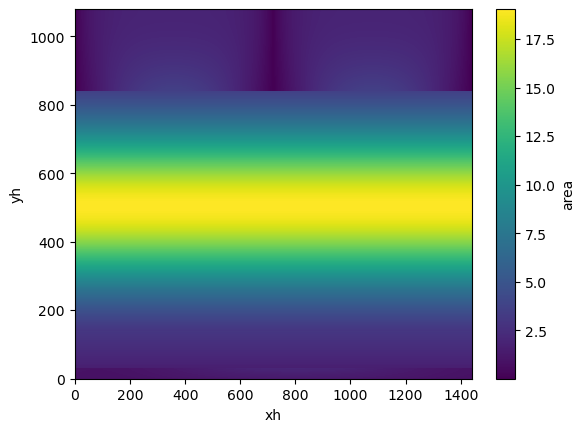

In [23]:
area_new.plot()

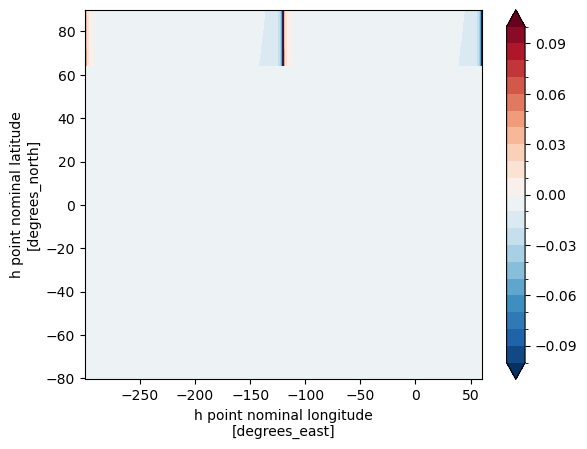

In [35]:
((area_new-area_expected)/area_expected).plot(vmax=0.1, levels=21)

Ok that seems pretty small